In [ ]:
#zanalysis

In [1]:
format short g

In [2]:
pkg install "https://github.com/gnu-octave/statistics-resampling/archive/refs/heads/master.zip"

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.7.0
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [3]:
pkg load statistics-resampling

In [4]:
[~, genotype] = xlsread ('../data/abeta-cleaned-ver3.xlsx', 'Sheet1', 'E2:E165');
[~, condition] = xlsread ('../data/abeta-cleaned-ver3.xlsx', 'Sheet1', 'F2:F165');

% for cell clusters am I averaging from the same cell into one data point
% need to load animal information once it is available

outcomes = xlsread ('../data/abeta-cleaned-ver3.xlsx', 'Sheet1', 'U2:AE163');

disp (size(genotype))
disp (size(condition))
disp (size(outcomes))

          162            1
          162            1
          162           11


In [7]:
for i = 1: size(outcomes, 2)
    MAT_T = bootlm (outcomes(:,i), {genotype, condition}, 'model', 'full', 'display', 'off', ...
            'contrasts', 'treatment', 'nboot', 0);
end

In [8]:
STATS_SRS = bootbayes(outcomes, MAT_T.X);

In [9]:
Deff = 1

Deff =     1


In [10]:
MAT_H = bootlm (outcomes(:,11), {genotype,condition}, 'model', 'full', ...
                'display', 'off', 'contrasts', 'helmert', 'nboot', 0, 'dim', [1,2]);
MAT_H.C

MAT_H = bootlm (outcomes(:,11), {genotype, condition}, 'model', 'full', ...
                'display', 'off', 'contrasts', MAT_H.C, 'nboot', 0, 'dim', [1,2]);
                
size (MAT_H.X)

ans =
{
  [1,1] =

           -0.5
            0.5

  [1,2] =

       -0.66667            0
        0.33333         -0.5
        0.33333          0.5

}

ans =

          162            6




 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 162

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 9.12219

 Predicted R-squared: 0.171 (17.1%)

 Bootstrap optimized ridge tuning constant (lambda): 3.90398

 Effective residual degrees of freedom (df_lambda): 157.

 Residual variances (range): [0.629, 0.928]

 Inferential degrees of freedom (df_t): 157.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.02540      -0.1820       +0.1324  
 1             3             +0.7310       +0.6483       +0.7967  
 1             4             +0.1763       +0.019

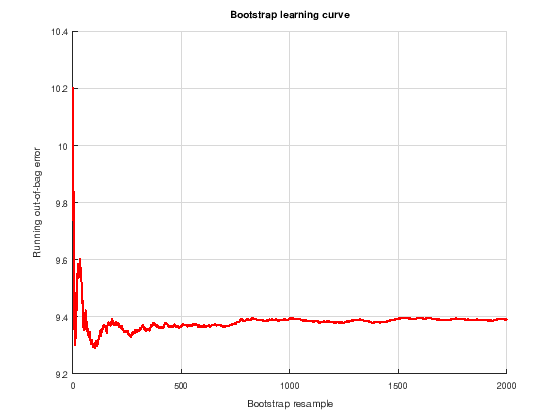

In [ ]:
tic
bootridge(outcomes, MAT_H.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;